In [2]:
# setup
import io
import base64
import sys
import glob
import errno
from collections import defaultdict
import os
import gc

import numpy as np
import cupy as cp
import h5py
import scipy as sp
import pandas as pd
import itertools
import multiprocessing as mproc
import pandas as pd
import PIL as pil
import rembg
import glob
import calendar

sys.path.append(os.getcwd())

%reload_ext autoreload
%autoreload 2

from IPython.display import display, HTML, Math, Latex
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

import matplotlib.pyplot as plt
# from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib as mpl
# from mpl_toolkits.mplot3d import Axes3D

from jsd import jsd

%matplotlib inline
#%matplotlib notebook
    
# mpl.rcParams['text.usetex'] = 'True'
mpl.rcParams['axes.grid'] = False
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.bottom'] = True
mpl.rcParams['ytick.left'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.major.size'] = 14
mpl.rcParams['ytick.major.size'] = 14
mpl.rcParams['xtick.minor.size'] = 7
mpl.rcParams['ytick.minor.size'] = 7
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['xtick.minor.width'] = 1.2
mpl.rcParams['ytick.minor.width'] = 1.2
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['legend.loc'] = 'best'
mpl.rcParams['legend.fontsize'] = 25
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.serif'] = 'Computer Modern'
mpl.rcParams['xtick.major.pad']='8'
mpl.rcParams['ytick.major.pad']='8'
mpl.rcParams['ytick.major.pad']='8'

blue = '#1f77b4'
orange = '#ff7f0e'
green = '#2ca02c'
red = '#ad494a'
violet = '#9467bd'
brown = '#8c564b'

In [ ]:
# read database
db = jsd('data/All_crop.xlsx')
# make month list
# db.make_month_list('data/All_crop_month_new.xlsx')

In [224]:
# read database
db = jsd('data/All_crop.xlsx')

# read generated month table
db.set_month_table('data/All_crop_month.xlsx')

# create lists of properties
crop_names = list(set(db.dataframe['Crop'].tolist()))
crop_names.sort()
crop_names.insert(0, 'All')
maturity_days = ['All', 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
crop_types = ['All', 'Hybrid', 'OP']
brand_names = ['All', 'Zillion', 'Chia Tai']
weather_tolerances = ['All', 'Rain', 'Heat', 'Rain & heat']
transport_properties = ['All', 'Good']

# generate list
variety_list = db.generate_list(crop_name='All', maturity_day=maturity_days[1], crop_type='All', brand_name='All', weather_tolerance='All', transport_property='All')
db.dataframe[variety_list]

,Variety,Crop,Hybrid or OP,Company,Sowing and transplant starting time,Sowing and transplant ending time,Best sowing and transplant starting time,Best sowing and transplant ending time,Maturity (days),After sowing or transplant,Weight (g),Fruit Size (cm),"Fruit shape, type, color",Disease Tolerance,Weather tolerance,Transport and storage property
28,F1 Hybrid Cucumber All Rounder,Cucumber,hybrid,Chia Tai,January,December,January,December,30-35,sowing,200-300,14,"green (summer), dark green (winter)",,,
31,F1 Hybrid Cucumber Fantasy-1,Cucumber,hybrid,Chia Tai,February,October,February,October,28-30,sowing,200,15,green,virus tolerant,"heat, rain tolerant",
32,F1 Hybrid Cucumber Fantasy-2,Cucumber,hybrid,Chia Tai,February,October,February,October,28-30,sowing,200,14,green,virus tolerant,"heat, rain tolerant",
35,F1 Hybrid Cucumber Shatabdi,Cucumber,hybrid,Chia Tai,January,December,January,December,30-35,sowing,150-200,12,green,,,
36,F1 Hybrid Cucumber Shatabdi-2,Cucumber,hybrid,Chia Tai,January,December,January,December,30-35,sowing,300,12,"oblong, green",downy mildew tolerant,,good
38,F1 Hybrid Cucumber Fantasy Green,Cucumber,hybrid,Zillion,February,October,February,October,30-35,sowing,180-200,2026-12-14 00:00:00,green,virus tolerant,"heat, rain tolerant",
112,F1 Hybrid Bitter Gourd Hazari-1,Bitter Gourd,hybrid,Zillion,January,December,January,December,30-35,sowing,60-65,,green,,,
135,Lettuce Grand Rapids,Lettuce,OP,Chia Tai,January,December,January,December,30,sowing,,,green color,,,


,Variety,Crop,Hybrid or OP,Company,Sowing and transplant starting time,Sowing and transplant ending time,Best sowing and transplant starting time,Best sowing and transplant ending time,Maturity (days),After sowing or transplant,Weight (g),Fruit Size (cm),"Fruit shape, type, color",Disease Tolerance,Weather tolerance,Transport and storage property
63,Yard Long Bean Baromashi Green,Yard Long Bean,OP,Chia Tai,January,December,January,December,38-40,sowing,,65,"green, long pod, purple and brownish-red seed ...",,,
64,Yard Long Bean Stickless,Yard Long Bean,OP,Chia Tai,January,December,January,December,50-55,sowing,,25-30,"green, short pod",disease tolerant,,
65,Yard Long Bean Green Pod,Yard Long Bean,OP,Chia Tai,January,September,January,September,50,sowing,,60,"dark green pod, black seed",,,
66,Yard Long Bean Yamuna,Yard Long Bean,OP,Chia Tai,January,September,January,September,50,transplant,,55,"light green pod, white seed",,,
124,Chinese Radish Durbar,Chinese Radish,OP,Chia Tai,March,October,March,October,35-40,sowing,200-500,30-35,white straight roots,,"heat, rain tolerant",
133,Papaya Thai Red Flesh,Papaya,OP,Chia Tai,January,December,January,December,90-120,transplant,3000-5000,,sweet ripe fruit with red flesh,disease Tolerant,,
135,Lettuce Grand Rapids,Lettuce,OP,Chia Tai,January,December,January,December,30,sowing,,,green color,,,


,Variety,Crop,Hybrid or OP,Company,Sowing and transplant starting time,Sowing and transplant ending time,Best sowing and transplant starting time,Best sowing and transplant ending time,Maturity (days),After sowing or transplant,Weight (g),Fruit Size (cm),"Fruit shape, type, color",Disease Tolerance,Weather tolerance,Transport and storage property
63,Yard Long Bean Baromashi Green,Yard Long Bean,OP,Chia Tai,January,December,January,December,38-40,sowing,,65,"green, long pod, purple and brownish-red seed ...",,,
64,Yard Long Bean Stickless,Yard Long Bean,OP,Chia Tai,January,December,January,December,50-55,sowing,,25-30,"green, short pod",disease tolerant,,
65,Yard Long Bean Green Pod,Yard Long Bean,OP,Chia Tai,January,September,January,September,50,sowing,,60,"dark green pod, black seed",,,
66,Yard Long Bean Yamuna,Yard Long Bean,OP,Chia Tai,January,September,January,September,50,transplant,,55,"light green pod, white seed",,,
124,Chinese Radish Durbar,Chinese Radish,OP,Chia Tai,March,October,March,October,35-40,sowing,200-500,30-35,white straight roots,,"heat, rain tolerant",
133,Papaya Thai Red Flesh,Papaya,OP,Chia Tai,January,December,January,December,90-120,transplant,3000-5000,,sweet ripe fruit with red flesh,disease Tolerant,,
135,Lettuce Grand Rapids,Lettuce,OP,Chia Tai,January,December,January,December,30,sowing,,,green color,,,


In [3]:
# read database
db = jsd('data/All_crop.xlsx')
# read generated month table
db.set_month_table('data/All_crop_month.xlsx')

# read database for a specific month
# db_july = jsd(db.is_month_inlist('July', best=None, bool_list=None))

mlist = np.ones((len(db.dataframe), 12), dtype=bool)
idx = 0
for month in calendar.month_name[1:]:
    mlist[:, idx] = db.is_month_inlist(month, best=None, bool_list=True)
    idx+=1

matlist = np.ones((len(db.dataframe), 10), dtype=bool)
idx = 0
for days in range(30, 80, 5):
    matlist[:, idx] = db.is_maturity_within(days, bool_list=True)
    idx+=1

matlist_sum = matlist.sum(axis=0)
matlist_sum[1:] = matlist_sum[1:] - matlist_sum[:-1]

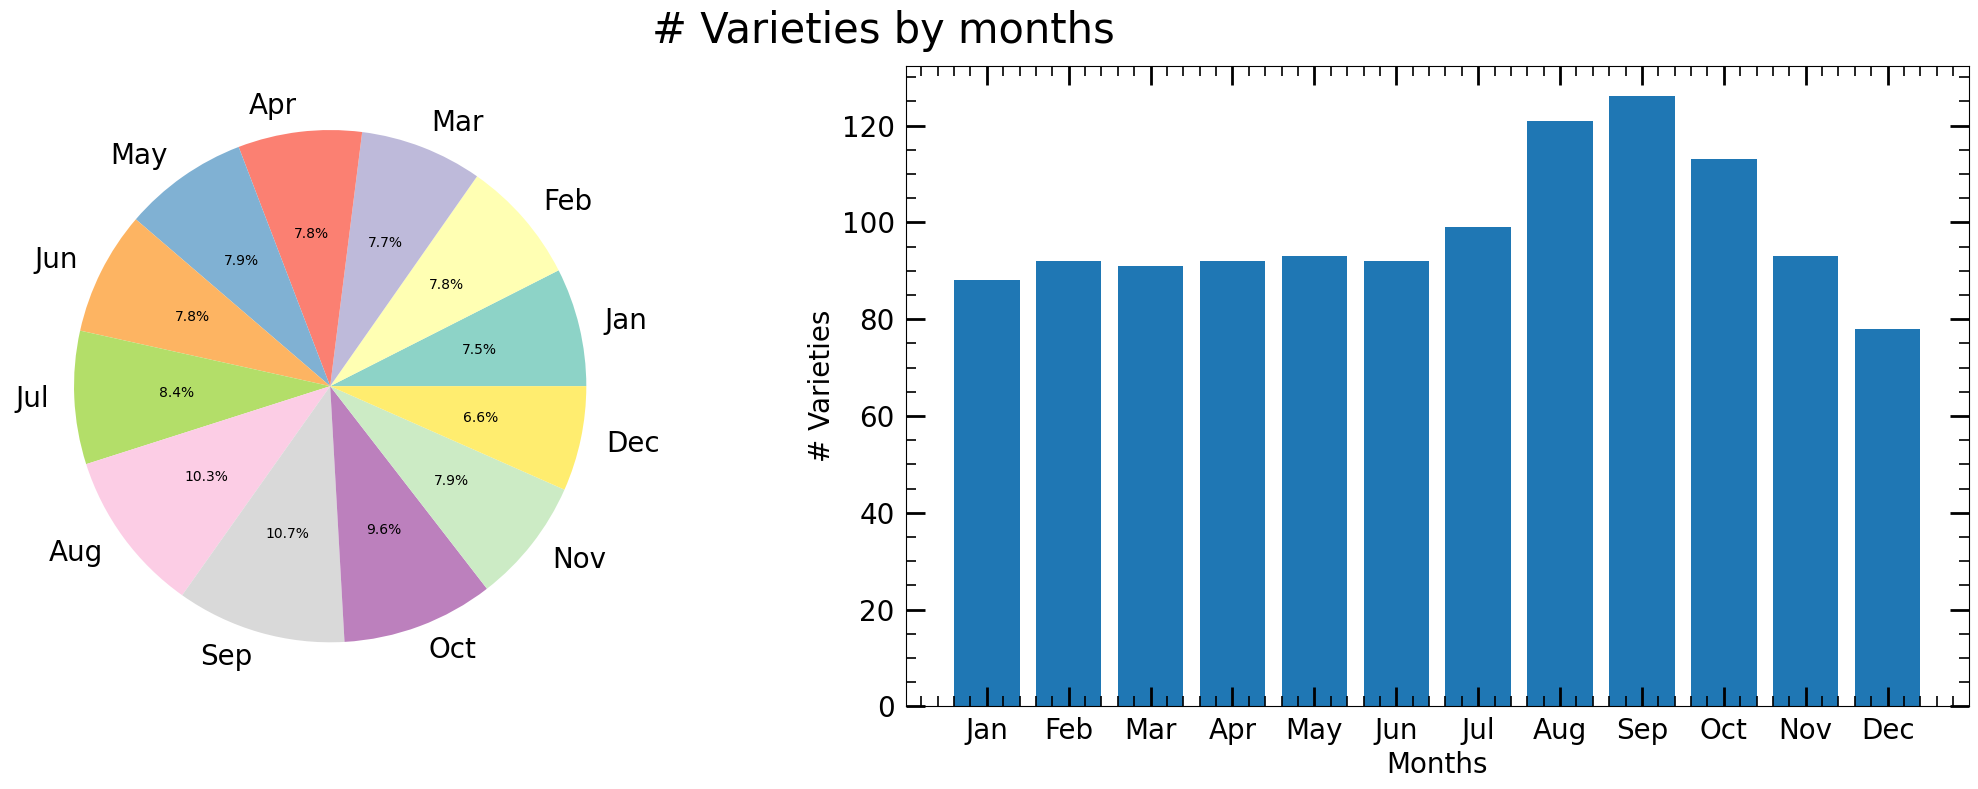

In [9]:
mpl.rcParams['figure.figsize'] = 22, 8

plt.subplot(1, 2, 1)
plt.pie(mlist.sum(axis=0), labels=calendar.month_abbr[1:], autopct='%1.1f%%', colors=mpl.colormaps['Set3'].colors)

plt.subplot(1, 2, 2)
plt.bar(calendar.month_abbr[1:], mlist.sum(axis=0), color=blue)
plt.xlabel('Months')
plt.ylabel('# Varieties')

plt.suptitle('# Varieties by months', fontsize=30)
plt.tight_layout()
plt.show()

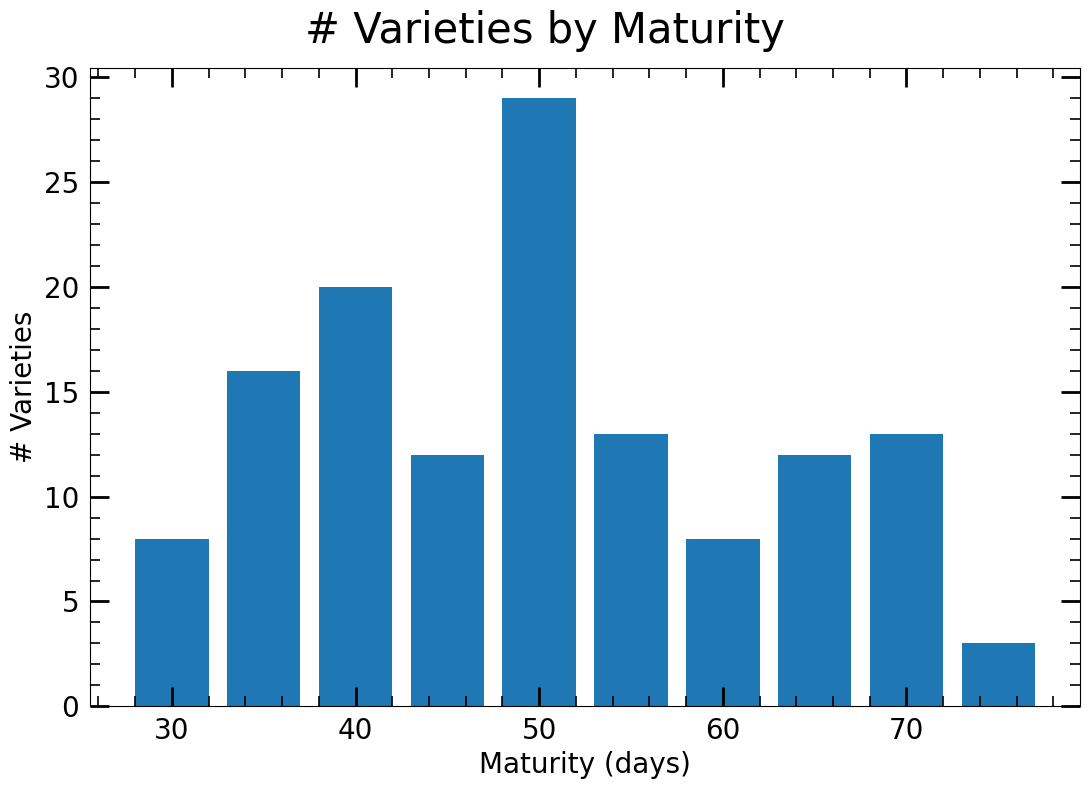

In [8]:
mpl.rcParams['figure.figsize'] = 11, 8

plt.bar(list(range(30, 80, 5)), matlist_sum, color=blue, width=4)
plt.xlabel('Maturity (days)')
plt.ylabel('# Varieties')

plt.suptitle('# Varieties by Maturity', fontsize=30)
plt.tight_layout()
plt.show()

In [237]:
from viewer import viewer
jsv = viewer()
jsv.run()